In [ ]:
### Import Libraries

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ML models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import accuracy_score, r2_score, confusion_matrix, classification_report


from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
### Import Dataset

In [5]:
df = pd.read_excel(r"C:\Users\HP\Downloads\Dataset.xlsx")
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NoCoupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [ ]:
### Exploratory Data Analysis

In [7]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

In [8]:
df.describe

<bound method NDFrame.describe of         OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card 

In [9]:
print(df## drop duplicates
df = data.drop_duplicates()
df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [10]:
## drop duplicates
df = df.drop_duplicates()
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NoCoupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


In [11]:
## As there are some entries without copon code so we are replacing them with NoCoupon
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")


In [12]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [ ]:
### Data Visulisation

In [ ]:
### Product Sales Analysis

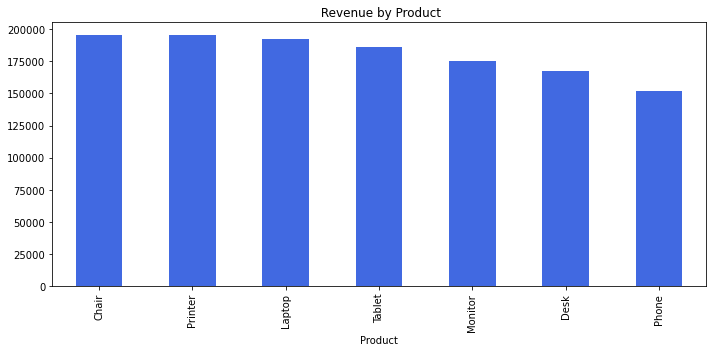

In [16]:
product_sales = df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
product_sales.plot(kind="bar",color ="royalblue")
plt.title(" Revenue by Product")
plt.tight_layout()
plt.show()

In [ ]:
### Order Status Analysis

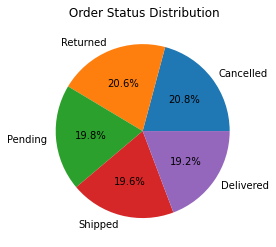

In [17]:
df["OrderStatus"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title(" Order Status Distribution")
plt.ylabel("")
plt.show()

In [ ]:
### Scatter plot

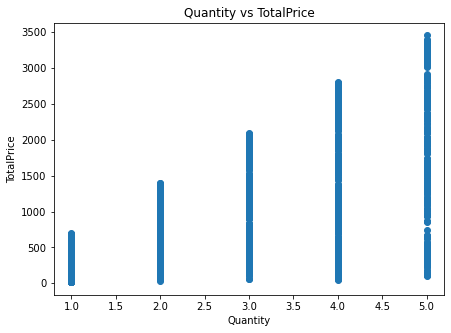

In [18]:
plt.figure(figsize=(7,5))
plt.scatter(df["Quantity"],df["TotalPrice"])
plt.xlabel("Quantity")
plt.ylabel("TotalPrice")
plt.title("Quantity vs TotalPrice")
plt.show()

In [ ]:
### Monthly Sales Trend

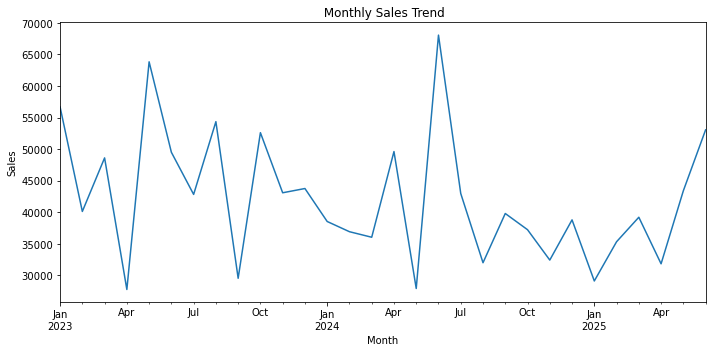

In [19]:
df["Month"] = pd.to_datetime(df["Date"]).dt.to_period("M")
Monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(10,5))
Monthly_sales.plot()
plt.title(" Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()